<a href="https://colab.research.google.com/github/Layaa-V/M25CSA017-NLU-A2/blob/main/NLU_A2_Q1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install requests beautifulsoup4 PyPDF2 nltk wordcloud matplotlib scikit-learn

In [ ]:
import os
import re
import requests
from bs4 import BeautifulSoup
import PyPDF2
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np
from collections import Counter
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device being used: {device}")

Device being used: cuda


In [ ]:
#data sources
URLS = ["https://www.iitj.ac.in/computer-science-engineering/en/undergraduate-programs",
    "https://www.iitj.ac.in/computer-science-engineering/en/postgraduate-programs",
    "https://www.iitj.ac.in/computer-science-engineering/en/doctoral-programs"]

pdf_folder = "data_pdfs"

In [ ]:
def scrape_webpage(url):
  response = requests.get(url, timeout=10)
  soup = BeautifulSoup(response.content, 'html.parser')
  paragraphs = soup.find_all('p')
  return " ".join([p.get_text() for p in paragraphs])

In [ ]:
def extract_pdf_text(folder_path):
    text = ""
    if not os.path.exists(folder_path):
        print(f"Warning: Directory '{folder_path}' not found. Please create it and add PDFs.")
        return text
    for filename in os.listdir(folder_path):
        if filename.endswith(".pdf"):
            filepath = os.path.join(folder_path, filename)
            with open(filepath, 'rb') as file:
                reader = PyPDF2.PdfReader(file)
                for page in reader.pages:
                    extracted = page.extract_text()
                    if extracted:
                        text += extracted + " "
    return text

In [ ]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    # Filter out stop words, very short words, and excessively long words
    filtered_tokens = [word for word in tokens if word not in stop_words and len(word) > 1 and len(word) <= 16]
    return filtered_tokens

In [ ]:
raw_corpus = ""
for url in URLS:
    raw_corpus += scrape_webpage(url) + " "
raw_corpus += extract_pdf_text(pdf_folder)

In [ ]:
tokens = preprocess_text(raw_corpus)
sentences = [tokens[i:i + 15] for i in range(0, len(tokens), 15)]
print(f"The final corpus(dataset) statistics")
print(f"Total Tokens: {len(tokens)}")
print(f"Vocabulary Size (Raw): {len(set(tokens))}")

The final corpus(dataset) statistics
Total Tokens: 14134
Vocabulary Size (Raw): 2207


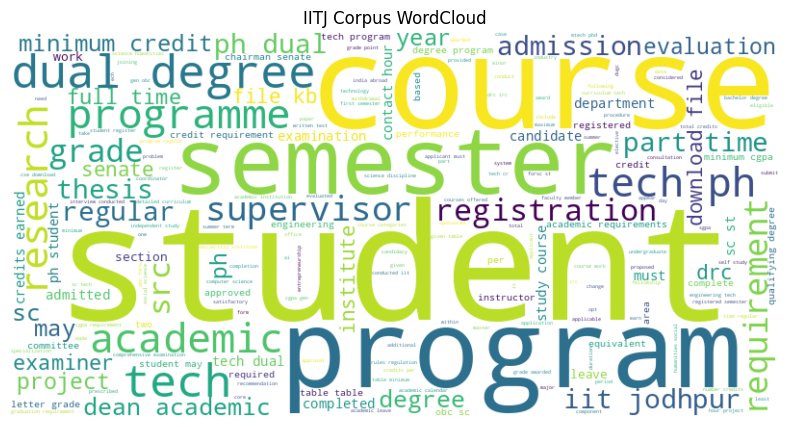

In [ ]:
if tokens:
  wordcloud = WordCloud(width=800, height=400, background_color='white').generate(" ".join(tokens))
  plt.figure(figsize=(10, 5))
  plt.imshow(wordcloud, interpolation='bilinear')
  plt.axis('off')
  plt.title("IITJ Corpus WordCloud")
  plt.show()

In [ ]:
# min_c kept at 1 so no words are dropped
min_c = 1
word_counts = Counter(tokens)
PAD_TOKEN = "<PAD>"
vocab = [PAD_TOKEN] + [w for w, c in word_counts.items() if c >= min_c]
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for i, w in enumerate(vocab)}
VOCAB_SIZE = len(vocab)
print(f"Filtered Vocabulary Size (min_count={min_c}, +PAD): {VOCAB_SIZE}")

#negative sampling dist
freqs = np.array([0] + [word_counts[w] for w in vocab[1:]])
freqs = freqs ** 0.75
freqs = freqs / np.sum(freqs)

Filtered Vocabulary Size (min_count=1, +PAD): 2208


In [ ]:
class W2VDataset(Dataset):
    def __init__(self, data, num_negatives, is_cbow=False):
        self.data = data
        self.num_negatives = num_negatives
        self.is_cbow = is_cbow

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        negatives = np.random.choice(VOCAB_SIZE, size=self.num_negatives, p=freqs)
        if self.is_cbow:
            contexts, target = self.data[idx]
            return torch.tensor(contexts, dtype=torch.long), torch.tensor(target, dtype=torch.long), torch.tensor(negatives, dtype=torch.long)
        else:
            target, context = self.data[idx]
            return torch.tensor(target, dtype=torch.long), torch.tensor(context, dtype=torch.long), torch.tensor(negatives, dtype=torch.long)

In [ ]:
def data_L(window, num_negatives, batch_size=128):
    sg_data = []
    cbow_data = []

    for sent in sentences:
        sent_idx = [word2idx[w] for w in sent if w in word2idx]
        for i, target in enumerate(sent_idx):
            start = max(0, i - window)
            end = min(len(sent_idx), i + window + 1)
            context = [sent_idx[j] for j in range(start, end) if j != i]

            for ctx in context:
                sg_data.append((target, ctx))

            padded_context = context + [word2idx[PAD_TOKEN]] * ((2 * window) - len(context))
            cbow_data.append((padded_context, target))

    sg_loader = DataLoader(W2VDataset(sg_data, num_negatives, is_cbow=False), batch_size=batch_size, shuffle=True)
    cbow_loader = DataLoader(W2VDataset(cbow_data, num_negatives, is_cbow=True), batch_size=batch_size, shuffle=True)
    return sg_loader, cbow_loader

In [ ]:
class SkipGramModel(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        self.target_embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.context_embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

    def forward(self, target, context, negatives):
        u = self.target_embed(target)
        v = self.context_embed(context)
        v_neg = self.context_embed(negatives)
        pos_score = torch.sum(u * v, dim=1)
        neg_score = torch.bmm(v_neg, u.unsqueeze(2)).squeeze(2)
        return pos_score, neg_score

In [ ]:
class CBOWModel(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        self.context_embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.target_embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

    def forward(self, context, target, negatives):
        v_ctx = self.context_embed(context).mean(dim=1)
        u_tgt = self.target_embed(target)
        u_neg = self.target_embed(negatives)
        pos_score = torch.sum(v_ctx * u_tgt, dim=1)
        neg_score = torch.bmm(u_neg, v_ctx.unsqueeze(2)).squeeze(2)
        return pos_score, neg_score

In [ ]:
def model_train(model, dataloader, epochs=5):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.BCEWithLogitsLoss()
    final_loss = 0

    for epoch in range(epochs):
        total_loss = 0
        for batch in dataloader:
            inputs, targets, negatives = [b.to(device) for b in batch]
            optimizer.zero_grad()
            pos_score, neg_score = model(inputs, targets, negatives)

            loss_pos = criterion(pos_score, torch.ones_like(pos_score))
            loss_neg = criterion(neg_score, torch.zeros_like(neg_score))

            loss = loss_pos + loss_neg
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        final_loss = total_loss / len(dataloader)
    return model, final_loss

In [ ]:
experiments = [
    {"dim": 50,  "win": 3, "neg": 3},
    {"dim": 100, "win": 5, "neg": 5}]

results = []
best_cbow_model = None
best_sg_model = None
EPOCHS = 8

In [ ]:
for exp in experiments:
    dim, win, neg = exp['dim'], exp['win'], exp['neg']
    print(f"\nconfig: Dim: {dim}, Window: {win}, Negatives: {neg}...")

    sg_loader, cbow_loader = data_L(win, neg)

    cbow_m, cbow_loss = model_train(CBOWModel(VOCAB_SIZE, dim), cbow_loader, epochs=EPOCHS)
    sg_m, sg_loss = model_train(SkipGramModel(VOCAB_SIZE, dim), sg_loader, epochs=EPOCHS)

    results.append(("CBOW", dim, win, neg, cbow_loss))
    results.append(("Skip-gram", dim, win, neg, sg_loss))

    if dim == 100 and win == 5:
        best_cbow_model = cbow_m
        best_sg_model = sg_m


config: Dim: 50, Window: 3, Negatives: 3...

config: Dim: 100, Window: 5, Negatives: 5...


In [ ]:
print(f"{'Model':<12}  {'Embed Dim':<10}  {'Window Size':<12}  {'Neg Samples':<12}  {'Final Loss':<12}")
for res in results:
    print(f" {res[0]:<12}  {res[1]:<10}  {res[2]:<12}  {res[3]:<12}  {res[4]:<12.4f}")

Model         Embed Dim   Window Size   Neg Samples   Final Loss  
 CBOW          50          3             3             0.5776      
 Skip-gram     50          3             3             0.6573      
 CBOW          100         5             5             0.3206      
 Skip-gram     100         5             5             0.6534      


In [ ]:
def get_embeddings(model):
    model.eval()
    if isinstance(model, SkipGramModel):
        return model.target_embed.weight.data.cpu().numpy()
    else:
        return model.target_embed.weight.data.cpu().numpy()

In [ ]:
def cosine_similarity(vec1, vec2):
    return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))

In [ ]:
def find_nearest_neighbors(word, embeddings, topn=5):
    if word not in word2idx:
        return [f"'{word}' not in vocab"]

    word_idx = word2idx[word]
    word_vec = embeddings[word_idx]

    similarities = []
    for i in range(1, VOCAB_SIZE):
        if i == word_idx: continue
        sim = cosine_similarity(word_vec, embeddings[i])
        similarities.append((idx2word[i], sim))

    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:topn]

In [ ]:
sg_embeddings = get_embeddings(best_sg_model)
cbow_embeddings = get_embeddings(best_cbow_model)
target_words = ['research', 'student', 'phd', 'exam']

print("\nCBOW nearest neighbors")
for word in target_words:
    neighbors = find_nearest_neighbors(word, cbow_embeddings)
    print(f"Top 5 for '{word}': {[n[0] for n in neighbors if isinstance(n, tuple)]}")

print("\nSkipgram nearest neighbors")
for word in target_words:
    neighbors = find_nearest_neighbors(word, sg_embeddings)
    print(f"Top 5 for '{word}': {[n[0] for n in neighbors if isinstance(n, tuple)]}")


CBOW nearest neighbors
Top 5 for 'research': ['selecting', 'demand', 'co', 'highly', 'carry']
Top 5 for 'student': ['proportional', 'bog', 'selection', 'fractalcourses', 'direction']
Top 5 for 'phd': ['second', 'considerable', 'using', 'alone', 'answer']
Top 5 for 'exam': ['fellowshipsr', 'act', 'government', 'cleared', 'subsection']

Skipgram nearest neighbors
Top 5 for 'research': ['proposal', 'labs', 'compute', 'scholars', 'idrps']
Top 5 for 'student': ['perform', 'within', 'ncc', 'submit', 'shall']
Top 5 for 'phd': ['mtech', 'doctor', 'dual', 'programs', 'philosophy']
Top 5 for 'exam': ['taking', 'cer', 'assessing', 'art', 'top']


In [ ]:
def custom_analogy(positive_words, negative_words, embeddings, model_name, analogy_name):
    print(f"\n[{model_name} Analogy: {analogy_name}]")
    all_words = positive_words + negative_words
    missing = [w for w in all_words if w not in word2idx]
    if missing:
        print(f"Skipping: Missing words {missing}")
        return

    pos_vecs = [embeddings[word2idx[w]] for w in positive_words]
    neg_vecs = [embeddings[word2idx[w]] for w in negative_words]
    target_vec = np.sum(pos_vecs, axis=0) - np.sum(neg_vecs, axis=0)
    similarities = []
    for i in range(1, VOCAB_SIZE):
        if idx2word[i] in all_words: continue
        sim = cosine_similarity(target_vec, embeddings[i])
        similarities.append((idx2word[i], sim))

    similarities.sort(key=lambda x: x[1], reverse=True)
    if similarities:
        print(f"Result: {similarities[0][0]} (Similarity: {similarities[0][1]:.3f})")

In [ ]:
analogies = [(['btech', 'postgraduate'], ['undergraduate'], "undergraduate : btech :: postgraduate : "),
    (['undergraduate', 'mtech'], ['btech'], "btech : undergraduate :: mtech : "),
    (['grade', 'thesis'], ['exam'], "exam : grade :: thesis : ")]

for pos, neg, name in analogies:
  custom_analogy(pos, neg, cbow_embeddings, "CBOW", name)
  custom_analogy(pos, neg, sg_embeddings, "Skip-gram", name)


[CBOW Analogy: undergraduate : btech :: postgraduate : ]
Result: conferences (Similarity: 0.416)

[Skip-gram Analogy: undergraduate : btech :: postgraduate : ]
Result: collaboration (Similarity: 0.472)

[CBOW Analogy: btech : undergraduate :: mtech : ]
Result: fresh (Similarity: 0.316)

[Skip-gram Analogy: btech : undergraduate :: mtech : ]
Result: oneoftheidrpco (Similarity: 0.328)

[CBOW Analogy: exam : grade :: thesis : ]
Result: capabilities (Similarity: 0.351)

[Skip-gram Analogy: exam : grade :: thesis : ]
Result: request (Similarity: 0.331)


In [ ]:
def plot_custom_embeddings(embeddings, title):
    words_to_plot = [idx2word[i] for i in range(1, min(151, VOCAB_SIZE))]
    word_vectors = np.array([embeddings[i] for i in range(1, min(151, VOCAB_SIZE))])

    perplexity = min(30, len(words_to_plot) - 1)
    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
    reduced_vectors = tsne.fit_transform(word_vectors)

    plt.figure(figsize=(12, 10))
    plt.scatter(reduced_vectors[:, 0], reduced_vectors[:, 1], c='mediumseagreen', edgecolors='k', alpha=0.7)

    for i, word in enumerate(words_to_plot):
        plt.annotate(word, xy=(reduced_vectors[i, 0], reduced_vectors[i, 1]),
                     xytext=(3, 3), textcoords='offset points', fontsize=8)

    plt.title(title)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

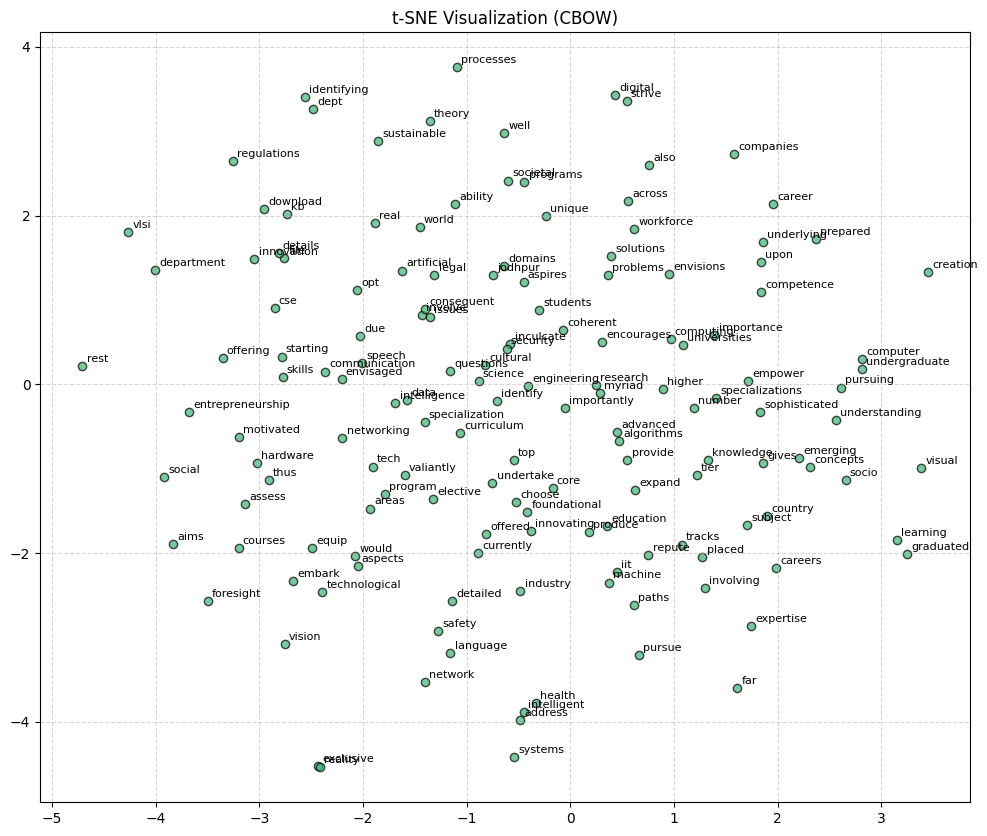

In [ ]:
plot_custom_embeddings(cbow_embeddings, "t-SNE Visualization (CBOW)")

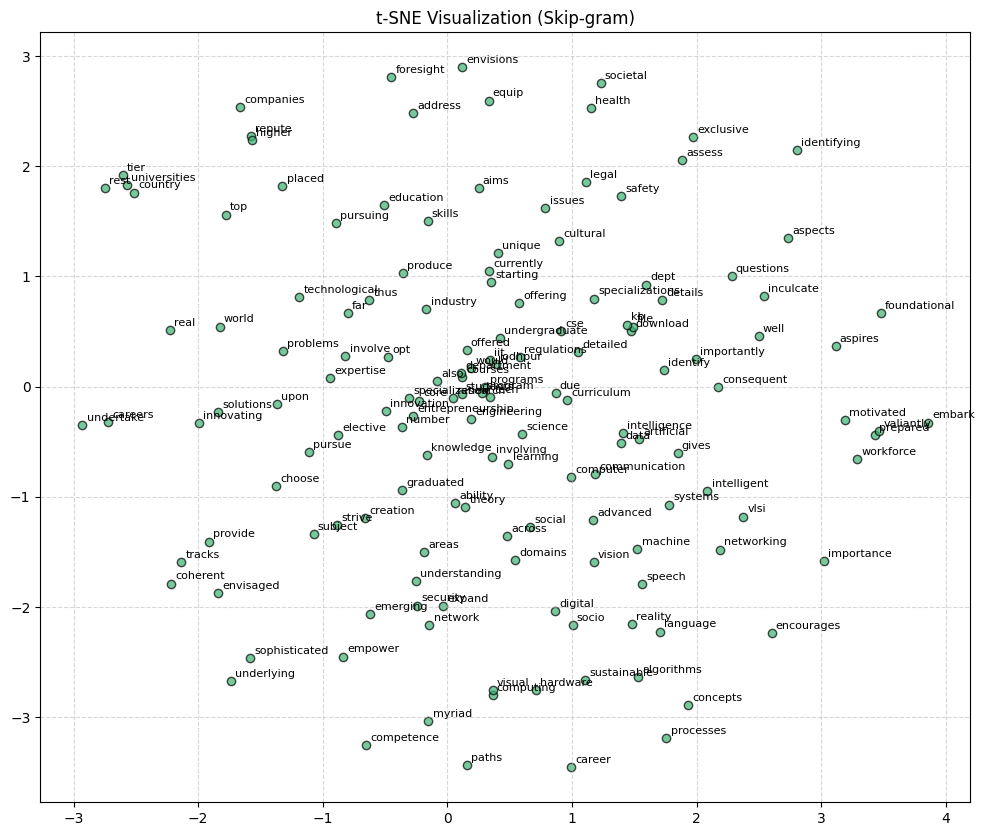

In [ ]:
plot_custom_embeddings(sg_embeddings, "t-SNE Visualization (Skip-gram)")

In [ ]:
output_file_path = "corpus.txt"
with open(output_file_path, "w") as f:
    f.write(" ".join(tokens))
print(f"Corpus saved")

Corpus saved
